In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

df = pd.read_csv('../data/processed_data.csv')

def plot_incidents_by_industry(df):
    counts = df.groupby('industry_name').size().reset_index(name='incident_count')
    counts = counts.sort_values('incident_count', ascending=True)
    fig = px.bar(counts, x='incident_count', y='industry_name', orientation='h',
                 title='Breach Incidents by Industry',
                 labels={'incident_count': 'Number of Incidents', 'industry_name': ''})
    fig.update_layout(height=500)
    return fig

def plot_cost_by_industry(df):
    cost = df.groupby('industry_name')['total_loss_usd'].mean().reset_index()
    cost.columns = ['industry_name', 'avg_cost']
    cost = cost.dropna().sort_values('avg_cost', ascending=True)
    fig = px.bar(cost, x='avg_cost', y='industry_name', orientation='h',
                 title='Average Breach Cost by Industry (USD)',
                 labels={'avg_cost': 'Average Total Loss (USD)', 'industry_name': ''})
    fig.update_xaxes(tickformat='$,.0f')
    fig.update_layout(height=500)
    return fig

def plot_attack_vector_comparison(df):
    counts = df.groupby('attack_vector_primary').size().reset_index(name='incident_count')
    cost = df.groupby('attack_vector_primary')['total_loss_usd'].mean().reset_index()
    cost.columns = ['attack_vector_primary', 'avg_cost']
    attack = counts.merge(cost, on='attack_vector_primary').sort_values('avg_cost', ascending=False)
    fig = make_subplots(rows=1, cols=2, subplot_titles=['Frequency', 'Avg Cost (USD)'])
    fig.add_trace(go.Bar(x=attack['incident_count'], y=attack['attack_vector_primary'],
                         orientation='h', name='Incidents'), row=1, col=1)
    fig.add_trace(go.Bar(x=attack['avg_cost'], y=attack['attack_vector_primary'],
                         orientation='h', name='Avg Cost'), row=1, col=2)
    fig.update_layout(title='Attack Vectors: Frequency vs Cost', showlegend=False, height=450)
    fig.update_xaxes(tickformat='$,.0f', row=1, col=2)
    return fig

def plot_yearly_trends(df):
    yearly = df.groupby('incident_year').agg(
        incident_count=('incident_id', 'count'),
        avg_cost=('total_loss_usd', 'mean')
    ).reset_index().dropna()
    fig = make_subplots(rows=1, cols=2, subplot_titles=['Incidents Per Year', 'Avg Cost Per Year'])
    fig.add_trace(go.Scatter(x=yearly['incident_year'], y=yearly['incident_count'],
                             mode='lines+markers', line=dict(width=3)), row=1, col=1)
    fig.add_trace(go.Scatter(x=yearly['incident_year'], y=yearly['avg_cost'],
                             mode='lines+markers', line=dict(width=3, color='crimson')), row=1, col=2)
    fig.update_layout(title='Breach Trends 2021-2025', showlegend=False, height=400)
    fig.update_yaxes(tickformat='$,.0f', row=1, col=2)
    return fig

def plot_cost_distribution(df):
    data = df.dropna(subset=['total_loss_usd'])
    data = data[data['total_loss_usd'] > 0].copy()
    data['log_cost'] = np.log1p(data['total_loss_usd'])
    fig = make_subplots(rows=1, cols=2, subplot_titles=['Raw Cost (USD)', 'Log Transformed'])
    fig.add_trace(go.Histogram(x=data['total_loss_usd'], nbinsx=50, name='Raw'), row=1, col=1)
    fig.add_trace(go.Histogram(x=data['log_cost'], nbinsx=50, name='Log',
                               marker_color='orange'), row=1, col=2)
    fig.update_layout(title='Breach Cost Distribution', showlegend=False, height=400)
    fig.update_xaxes(tickformat='$,.0f', row=1, col=1)
    return fig

def plot_stock_price_timeline(df):
    market = df.dropna(subset=['price_7d_before', 'price_disclosure_day',
                                'price_1d_after', 'price_7d_after', 'price_30d_after'])
    avg_prices = {
        '7d Before': market['price_7d_before'].mean(),
        'Disclosure Day': market['price_disclosure_day'].mean(),
        '1d After': market['price_1d_after'].mean(),
        '7d After': market['price_7d_after'].mean(),
        '30d After': market['price_30d_after'].mean()
    }
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=list(avg_prices.keys()), y=list(avg_prices.values()),
                             mode='lines+markers', line=dict(width=3, color='crimson'),
                             marker=dict(size=10)))
    fig.update_layout(title='Average Stock Price Around Breach Disclosure',
                      xaxis_title='Timeline', yaxis_title='Avg Stock Price (USD)',
                      yaxis_tickformat='$,.2f', height=400)
    return fig

def plot_cost_by_company_size(df):
    data = df.dropna(subset=['total_loss_usd', 'company_revenue_usd'])
    data = data[data['company_revenue_usd'] > 0].copy()
    data['log_revenue'] = np.log1p(data['company_revenue_usd'])
    data['log_cost'] = np.log1p(data['total_loss_usd'])
    fig = px.scatter(data, x='log_revenue', y='log_cost',
                     color='industry_name', hover_data=['company_name', 'attack_vector_primary'],
                     title='Company Size vs Breach Cost (Log Scale)',
                     labels={'log_revenue': 'Log(Company Revenue)', 'log_cost': 'Log(Breach Cost)'})
    fig.update_layout(height=500)
    return fig

print("All functions loaded successfully")

All functions loaded successfully


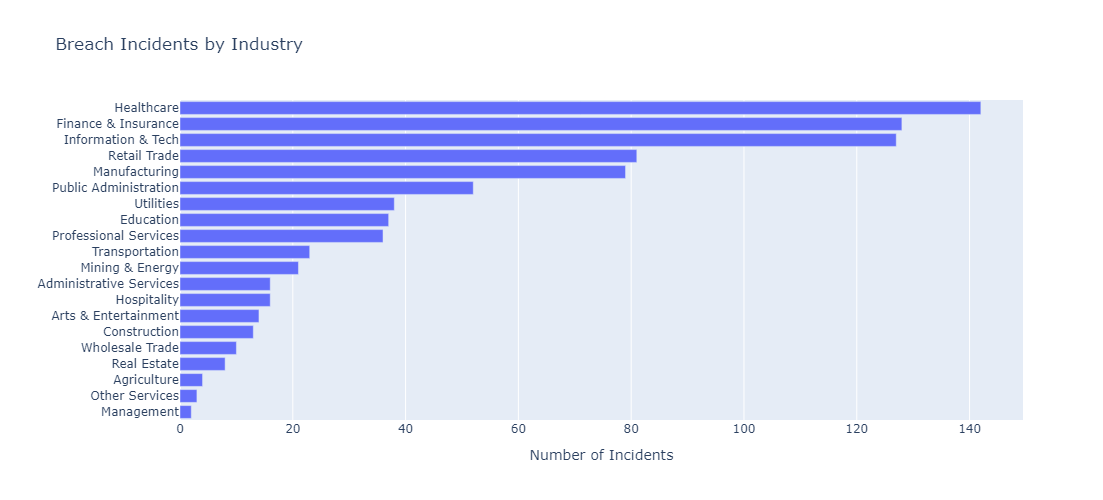

In [2]:
plot_incidents_by_industry(df).show()

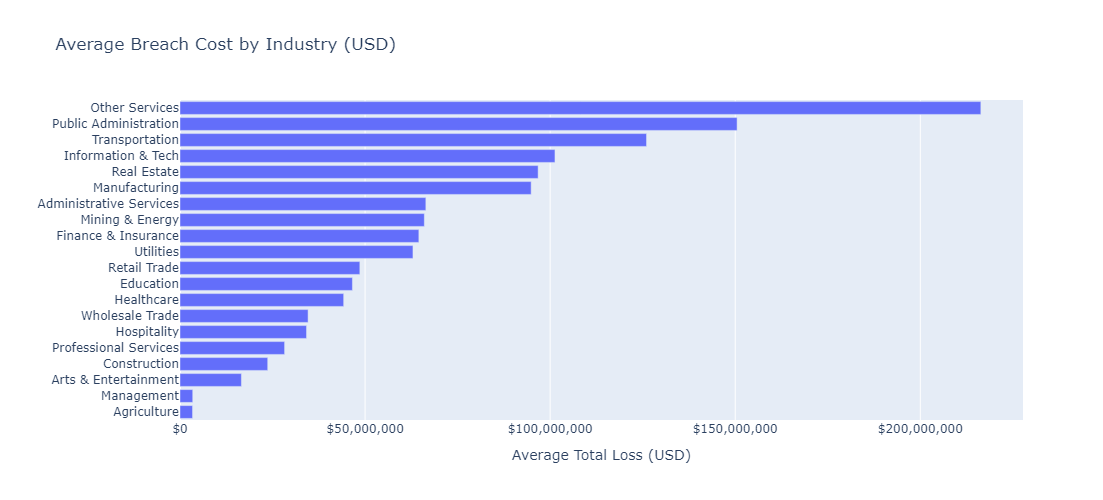

In [3]:
plot_cost_by_industry(df).show()

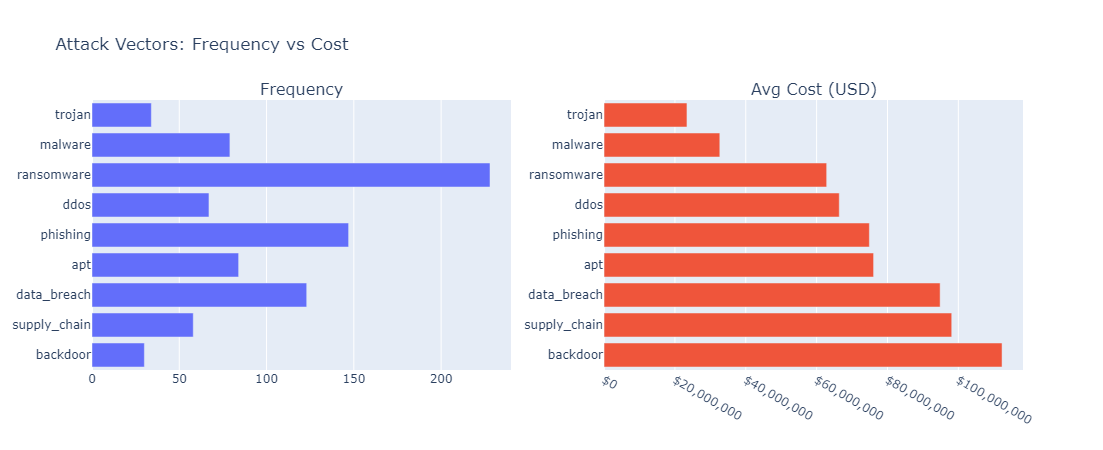

In [4]:
plot_attack_vector_comparison(df).show()

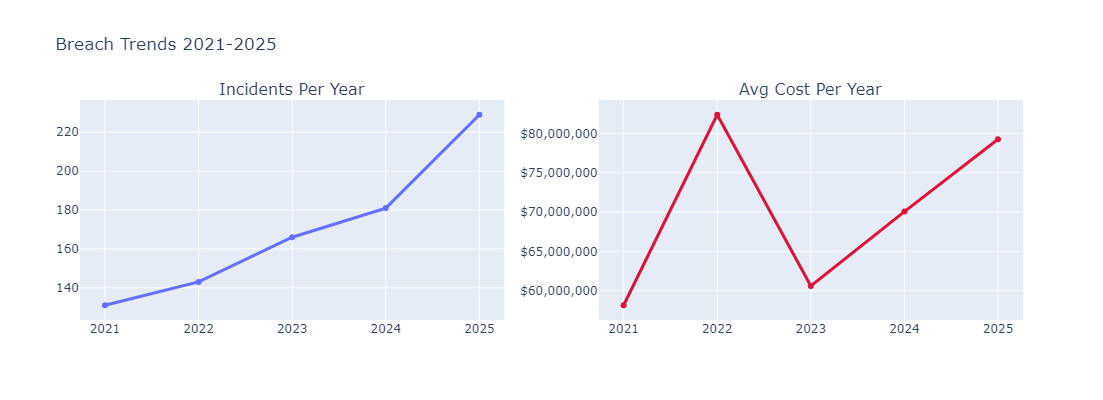

In [5]:
plot_yearly_trends(df).show()

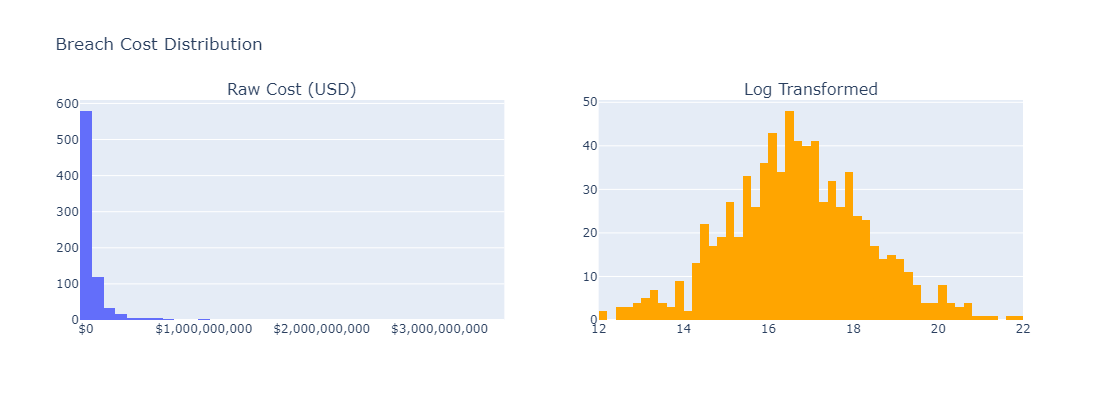

In [6]:
plot_cost_distribution(df).show()

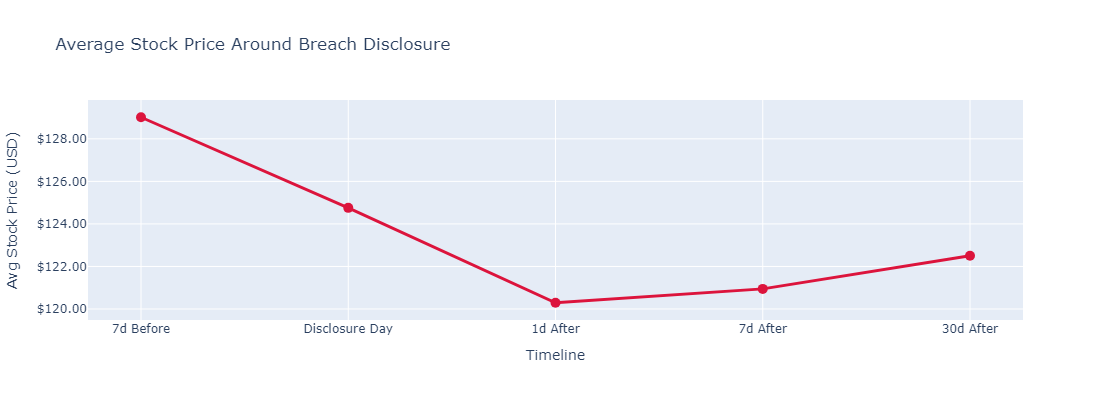

In [7]:
plot_stock_price_timeline(df).show()

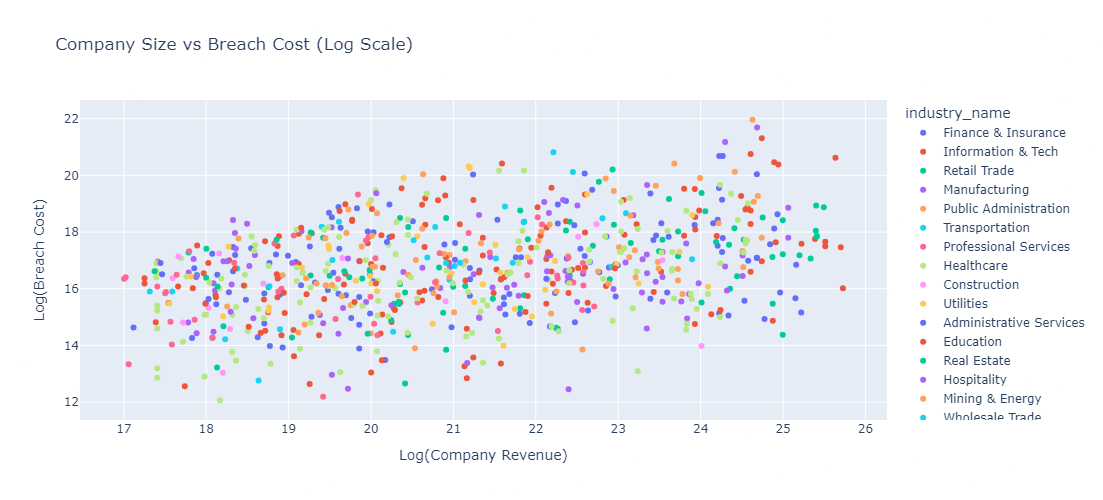

In [8]:
plot_cost_by_company_size(df).show()